# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)


A figure is the overall container that hods the entire visualizon, while an axes is the specific plotting area inside the figure where the data is actually drawn.


**2.** Name the three figure-level functions in `seaborn`.


relplot()
catplot()
displot()


**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?


A histogram displays the distribution of a numeric variable by grouping values into bins. 
A barplot compares categrical groups using aggregated statistics such as the mean. 
the plot used to show the distribution of a numeric variable is the histogram.  

## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

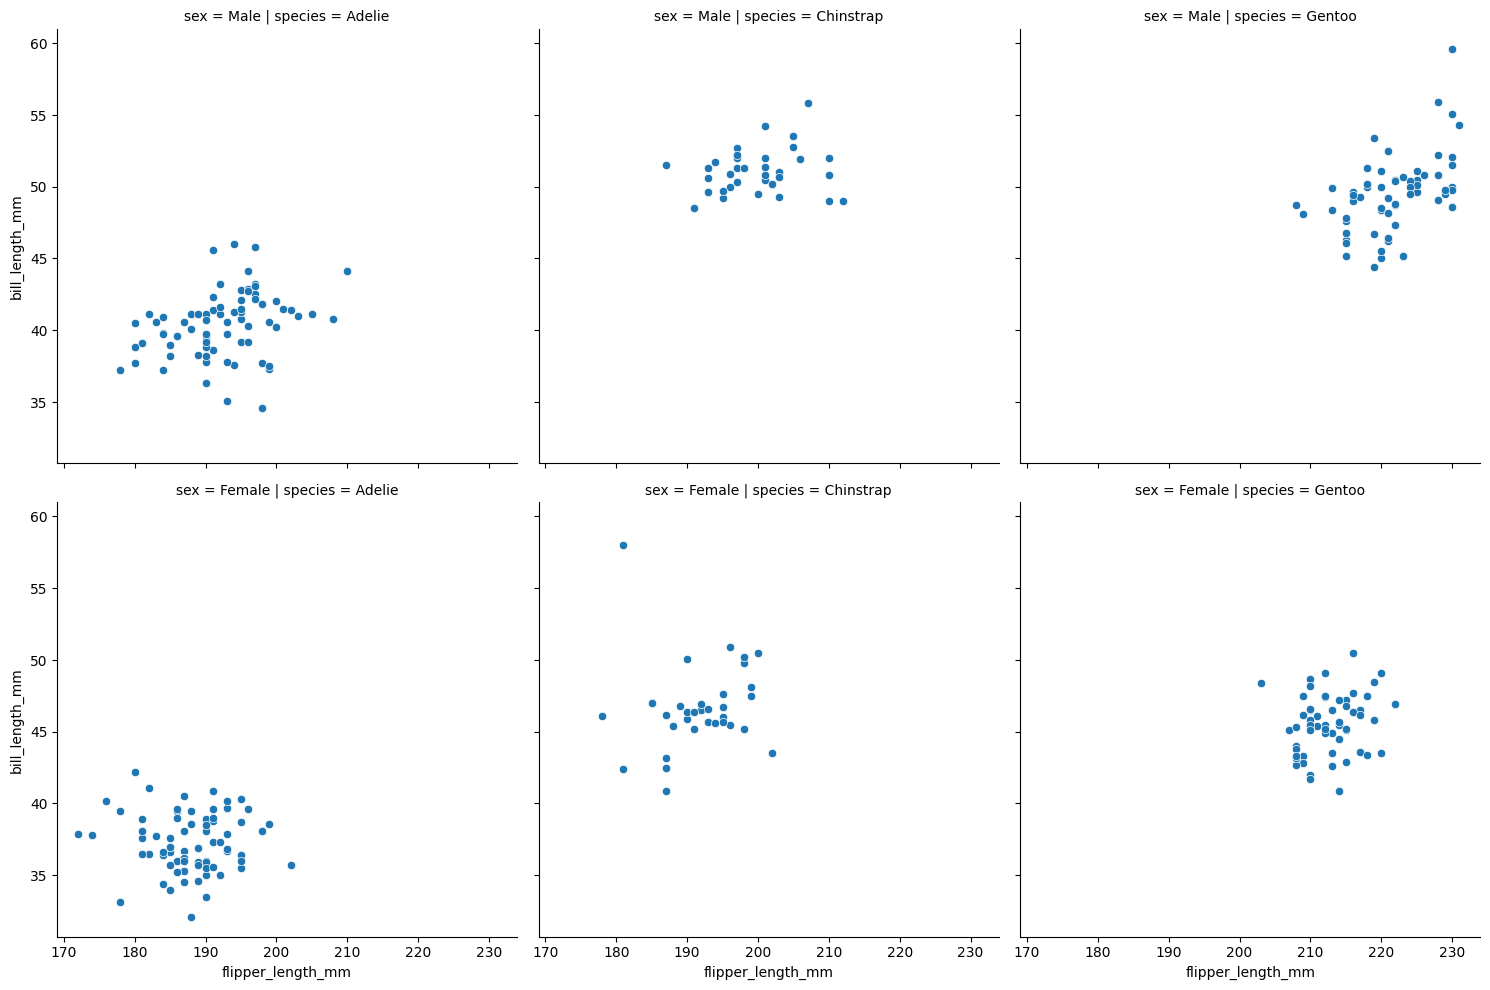

In [6]:
sns.relplot(
    data=df,
    x="flipper_length_mm",
    y="bill_length_mm",
    col="species",
    row="sex",
    kind="scatter"
)
plt.show()

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

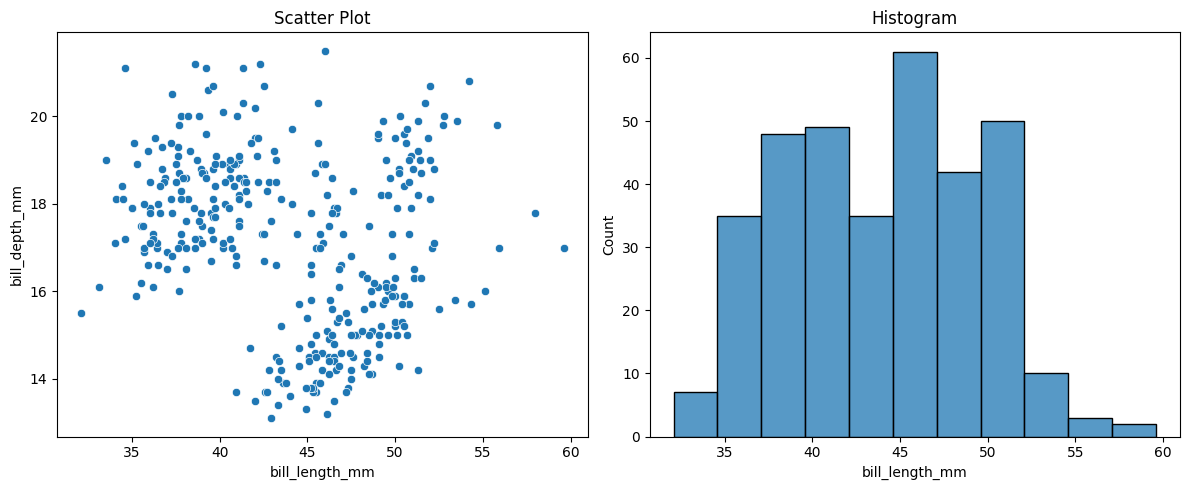

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatterplot
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    ax=axes[0]
)
axes[0].set_title("Scatter Plot")

# Histogram
sns.histplot(
    data=df,
    x="bill_length_mm",
    ax=axes[1]
)
axes[1].set_title("Histogram")

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

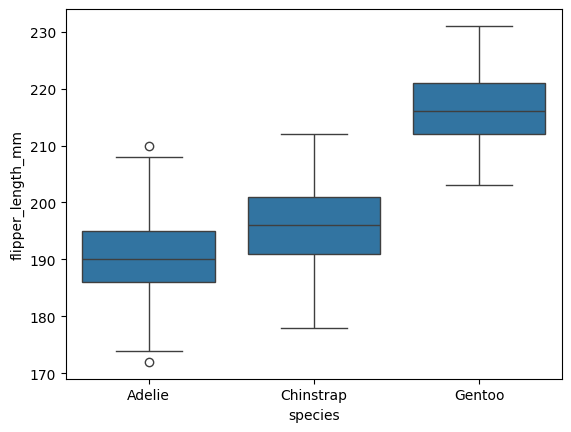

In [8]:
sns.boxplot(
    data=df,
    x="species",
    y="flipper_length_mm"
)
plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



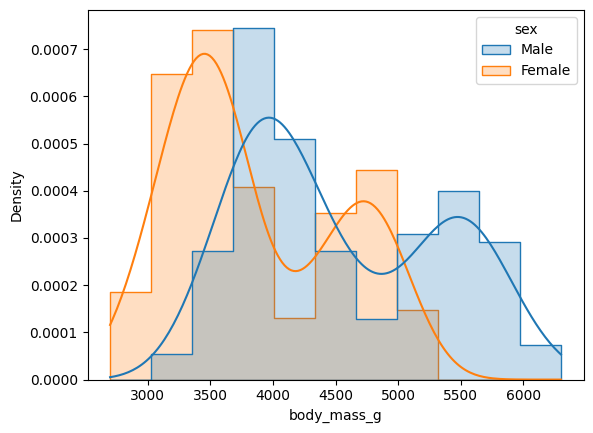

In [9]:
sns.histplot(
    data=df,
    x="body_mass_g",
    hue="sex",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



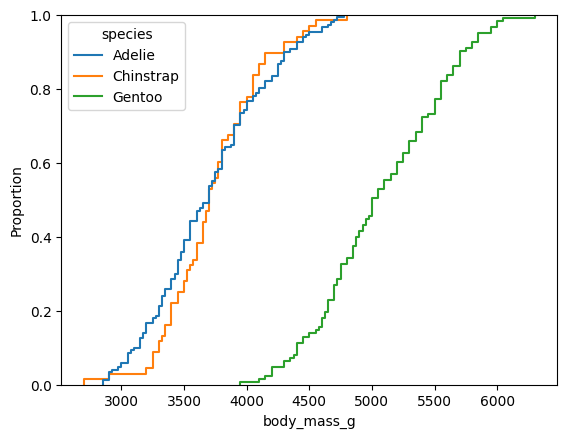

In [10]:
sns.ecdfplot(
    data=df,
    x="body_mass_g",
    hue="species"
)
plt.show()



*(Your interpretation here)*



**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



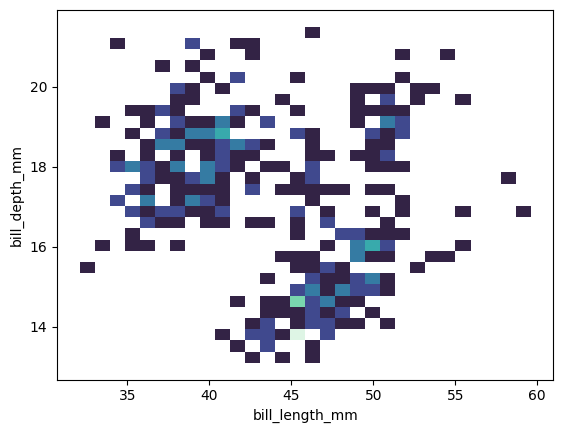

In [11]:
sns.histplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    bins=30,
    cmap="mako"
)
plt.show()

## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

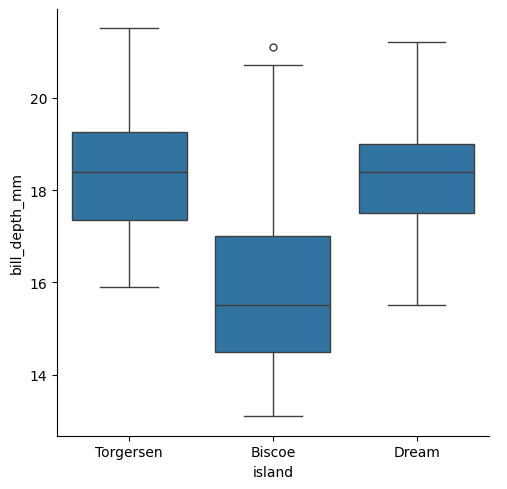

In [12]:
sns.catplot(
    data=df,
    x="island",
    y="bill_depth_mm",
    kind="box"
)
plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

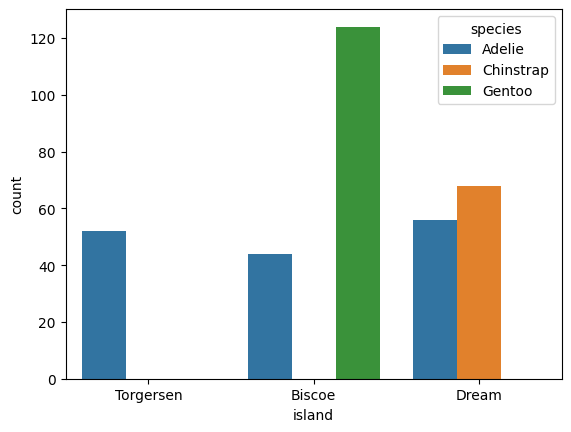

In [13]:
sns.countplot(
    data=df,
    x="island",
    hue="species"
)
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

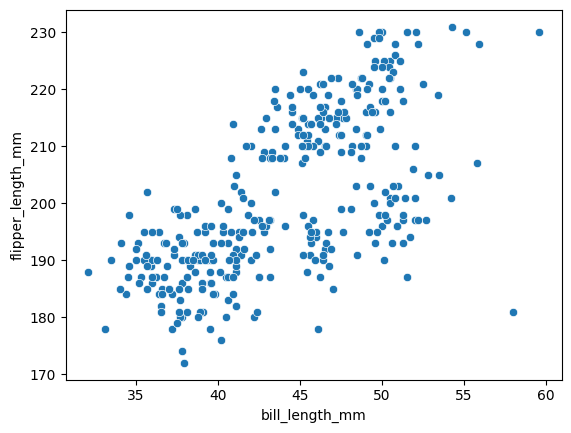

In [14]:
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm"
)
plt.show()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

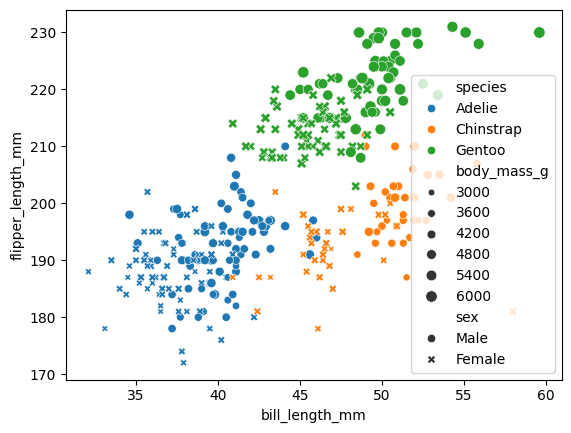

In [15]:
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="sex",
    size="body_mass_g"
)
plt.show()